In [1]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# set_theme: 테마 지정
sns.set_theme(style="whitegrid")

# 폰트 깨짐 방지
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

---
## **실습 1 - 산점도로 두 변수 관계 보기**
`scatterplot으로 두 센서의 관계를 점으로 확인`

<class 'pandas.DataFrame'>
RangeIndex: 297 entries, 0 to 296
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   라인      297 non-null    str    
 1   소입로온도   297 non-null    float64
 2   제어출력    297 non-null    float64
 3   건조출력    297 non-null    float64
 4   세정기     297 non-null    float64
 5   CP값     297 non-null    float64
 6   판정      297 non-null    str    
dtypes: float64(5), str(2)
memory usage: 16.4 KB


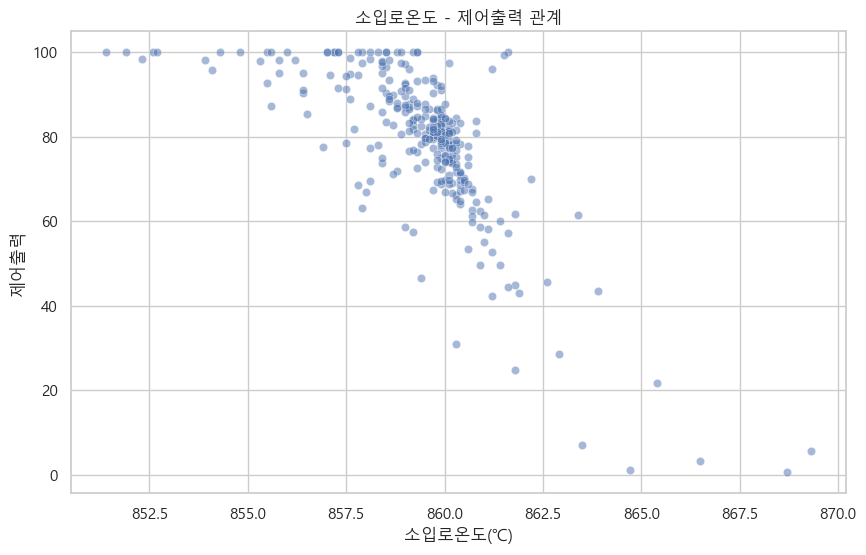

소입로온도 ~ 제어출력 상관계수: -0.736


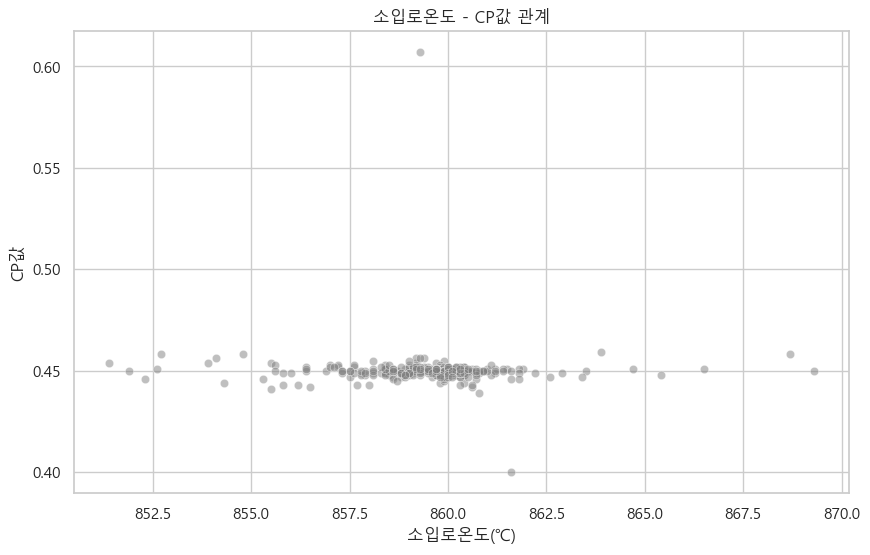

소입로온도 ~ CP값 상관계수: -0.026


In [3]:
df_1 = pd.read_csv("..\\Data\\18_열처리.csv", encoding="utf-8")
df_1.info()

# x, y에 두 센서를 지정해 산점도 그리기
# alpha로 겹친 점을 반투명 처리
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_1, x="소입로온도", y="제어출력", alpha=0.5)

# 제목, 축 이름을 붙이고 관계 방향 읽기
plt.title("소입로온도 - 제어출력 관계")
plt.xlabel("소입로온도(℃)")
plt.ylabel("제어출력")
plt.show()

# 눈으로 본 방향을 숫자로 확인
print("소입로온도 ~ 제어출력 상관계수:", df_1["소입로온도"].corr(df_1["제어출력"]).round(3))

# 비교용 - 관계가 거의 없는 쌍도 같이 그려보기
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_1, x="소입로온도", y="CP값", alpha=0.5, color="gray")
plt.title("소입로온도 - CP값 관계")
plt.xlabel("소입로온도(℃)")
plt.ylabel("CP값")
plt.show()

print("소입로온도 ~ CP값 상관계수:", df_1["소입로온도"].corr(df_1["CP값"]).round(3))

# [해석]
# 소입로온도-제어출력은 점들이 우하향 띠를 이루고 r = -0.736으로 뚜렷한 음의 관계
# 소입로온도-CP값은 점들이 사각형처럼 퍼져 있고 r = -0.026으로 사실상 무관

---
## **실습 2 - 판정별 산점도 패턴**
`hue로 양품, 불량을 색 구분해 위험 영역 찾기`

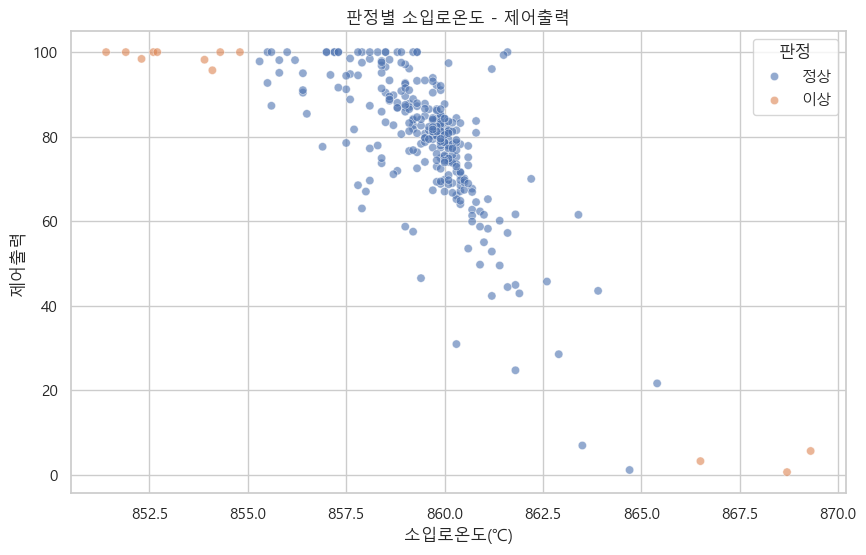

[판정별 센서 평균]
     소입로온도   제어출력   건조출력    세정기   CP값
판정                                   
이상  856.88  75.14  22.12  67.32  0.45
정상  859.53  79.17  22.16  66.97  0.45

[판정별 소입로온도 범위]
    count    min    max    mean   std
판정                                   
이상     12  851.4  869.3  856.88  6.91
정상    285  855.3  865.4  859.53  1.42


In [4]:
df_2 = pd.read_csv("..\\Data\\18_열처리.csv", encoding="utf-8")

# x, y에 두 센서, hue에 판정을 지정
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_2, x="소입로온도", y="제어출력", hue="판정", alpha=0.6)
plt.title("판정별 소입로온도 - 제어출력")
plt.xlabel("소입로온도(℃)")
plt.ylabel("제어출력")
plt.show()

# 산점도에서 불량 점이 몰린 영역 확인
# 판정별로 센서 평균을 비교해 어느 쪽으로 치우쳤는지 숫자로 확인
print("[판정별 센서 평균]")
print(df_2.groupby("판정")[["소입로온도", "제어출력", "건조출력", "세정기", "CP값"]].mean().round(2))

# 어느 영역이 위험 영역인지 해석
# 평균만 보면 차이가 작으므로 최솟값, 최댓값까지 같이 본다
print()
print("[판정별 소입로온도 범위]")
print(df_2.groupby("판정")["소입로온도"].agg(["count", "min", "max", "mean", "std"]).round(2))

# [해석]
# 이상 12건의 평균 온도(856.9도)는 정상(859.5도)보다 오히려 낮다
# 그런데 범위를 보면 이상은 851.4~869.3(폭 17.9), 정상은 855.3~865.4(폭 10.1)
# -> 위험 영역은 "온도가 높은 곳"이 아니라 "정상 띠의 양쪽 바깥" 이다

---
## **실습 3 - 센서 상관관계 heatmap**
`상관행렬을 heatmap으로 그리고 강한 쌍을 정리`

       소입로온도   제어출력   건조출력    세정기    CP값
소입로온도  1.000 -0.736 -0.007  0.032 -0.026
제어출력  -0.736  1.000  0.088 -0.019  0.009
건조출력  -0.007  0.088  1.000 -0.053 -0.095
세정기    0.032 -0.019 -0.053  1.000 -0.043
CP값   -0.026  0.009 -0.095 -0.043  1.000


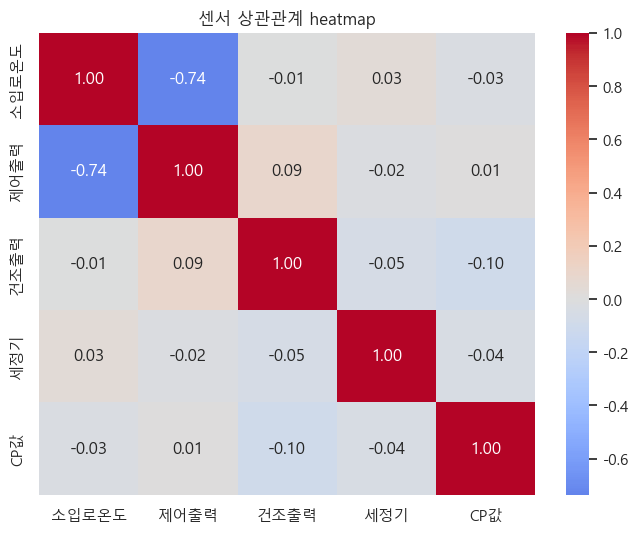


[절댓값이 큰 순서]
소입로온도  제어출력    -0.736
CP값    건조출력    -0.095
건조출력   제어출력     0.088
       세정기     -0.053
CP값    세정기     -0.043
세정기    소입로온도    0.032
CP값    소입로온도   -0.026
세정기    제어출력    -0.019
CP값    제어출력     0.009
건조출력   소입로온도   -0.007
dtype: float64


In [5]:
df_3 = pd.read_csv("..\\Data\\18_열처리.csv", encoding="utf-8")

# corr로 숫자 컬럼끼리 상관행렬 만들기
corr_3 = df_3.corr(numeric_only=True)
print(corr_3.round(3))

# heatmap에 annot, cmap, center를 주어 색과 숫자로 표현
# center=0을 줘야 양수와 음수가 다른 색으로 갈린다
plt.figure(figsize=(8, 6))
sns.heatmap(data=corr_3, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("센서 상관관계 heatmap")
plt.show()

# 대각선을 제외하고 절댓값이 큰 쌍만 골라 정리
# unstack으로 표를 세로로 펴고, 자기 자신끼리의 1.0을 걸러낸다
쌍 = corr_3.unstack()
쌍 = 쌍[쌍.index.get_level_values(0) < 쌍.index.get_level_values(1)]
print()
print("[절댓값이 큰 순서]")
print(쌍.reindex(쌍.abs().sort_values(ascending=False).index).round(3))

# [해석]
# 소입로온도 ~ 제어출력 = -0.736 하나만 뚜렷하고, 나머지 9쌍은 전부 절댓값 0.1 미만
# 센서가 5개라도 실제로 함께 움직이는 쌍은 1개뿐이라는 뜻

---
## **실습 4 - 종합 리포트 (분포, 박스플롯)**
`한 화면에 개수, 분포, 박스플롯을 나란히 배치`

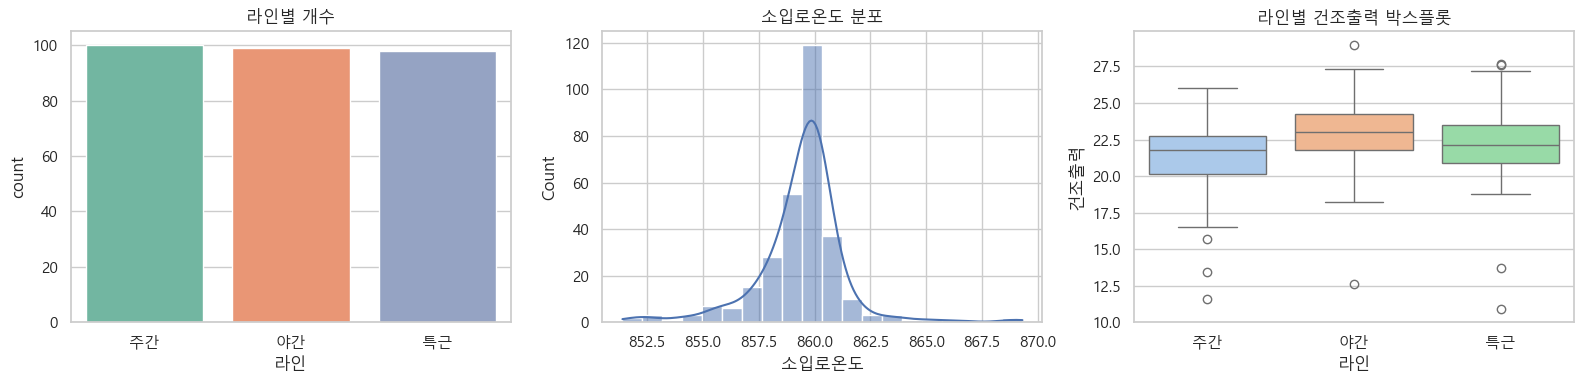

In [6]:
df_4 = pd.read_csv("..\\Data\\18_열처리.csv", encoding="utf-8")

# subplots로 가로 3칸을 만들기
# fig는 전체 도화지, axs는 각 칸을 가리키는 배열
fig, axs = plt.subplots(1, 3, figsize=(16, 4))

# 각 칸에 라인별 개수, 온도 분포, 건조출력 박스플롯을 그리기
# seaborn 함수는 ax= 로 어느 칸에 그릴지 지정한다
sns.countplot(data=df_4, x="라인", hue="라인", palette="Set2", legend=False, ax=axs[0])
axs[0].set_title("라인별 개수")

sns.histplot(data=df_4, x="소입로온도", bins=20, kde=True, ax=axs[1])
axs[1].set_title("소입로온도 분포")

sns.boxplot(data=df_4, x="라인", y="건조출력", hue="라인", palette="pastel", legend=False, ax=axs[2])
axs[2].set_title("라인별 건조출력 박스플롯")

# 각 축에 제목을 달고 tight_layout으로 정리
plt.tight_layout()
plt.show()

---
## **실습 5 - 종합 리포트 (산점도, heatmap)**
`관계 그래프 두 가지를 한 화면에 배치`

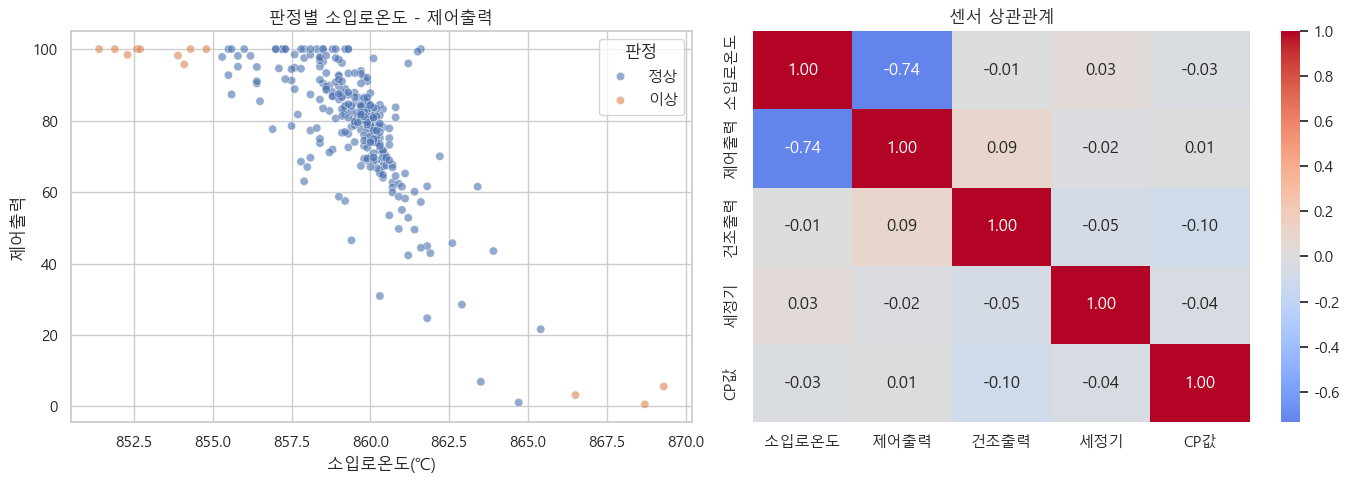

In [7]:
df_5 = pd.read_csv("..\\Data\\18_열처리.csv", encoding="utf-8")

# subplots로 가로 2칸을 만들기
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

# 왼쪽에 판정별 산점도 그리기
sns.scatterplot(data=df_5, x="소입로온도", y="제어출력", hue="판정", alpha=0.6, ax=axs[0])
axs[0].set_title("판정별 소입로온도 - 제어출력")
axs[0].set_xlabel("소입로온도(℃)")
axs[0].set_ylabel("제어출력")

# 오른쪽에 상관 heatmap 그리기
corr_5 = df_5.corr(numeric_only=True)
sns.heatmap(data=corr_5, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=axs[1])
axs[1].set_title("센서 상관관계")

# 각 축에 제목을 달고 tight_layout으로 정리
plt.tight_layout()
plt.show()

# [해석]
# 왼쪽 산점도의 우하향 띠가 오른쪽 heatmap의 -0.74 칸과 같은 사실을 말하고 있다
# 그림과 숫자를 나란히 두면 서로를 검산해 준다

---
## **실습 6 - 시각화 리포트 통합 / 저장**
`핵심 그래프 4개를 2x2로 모아 리포트로 저장`

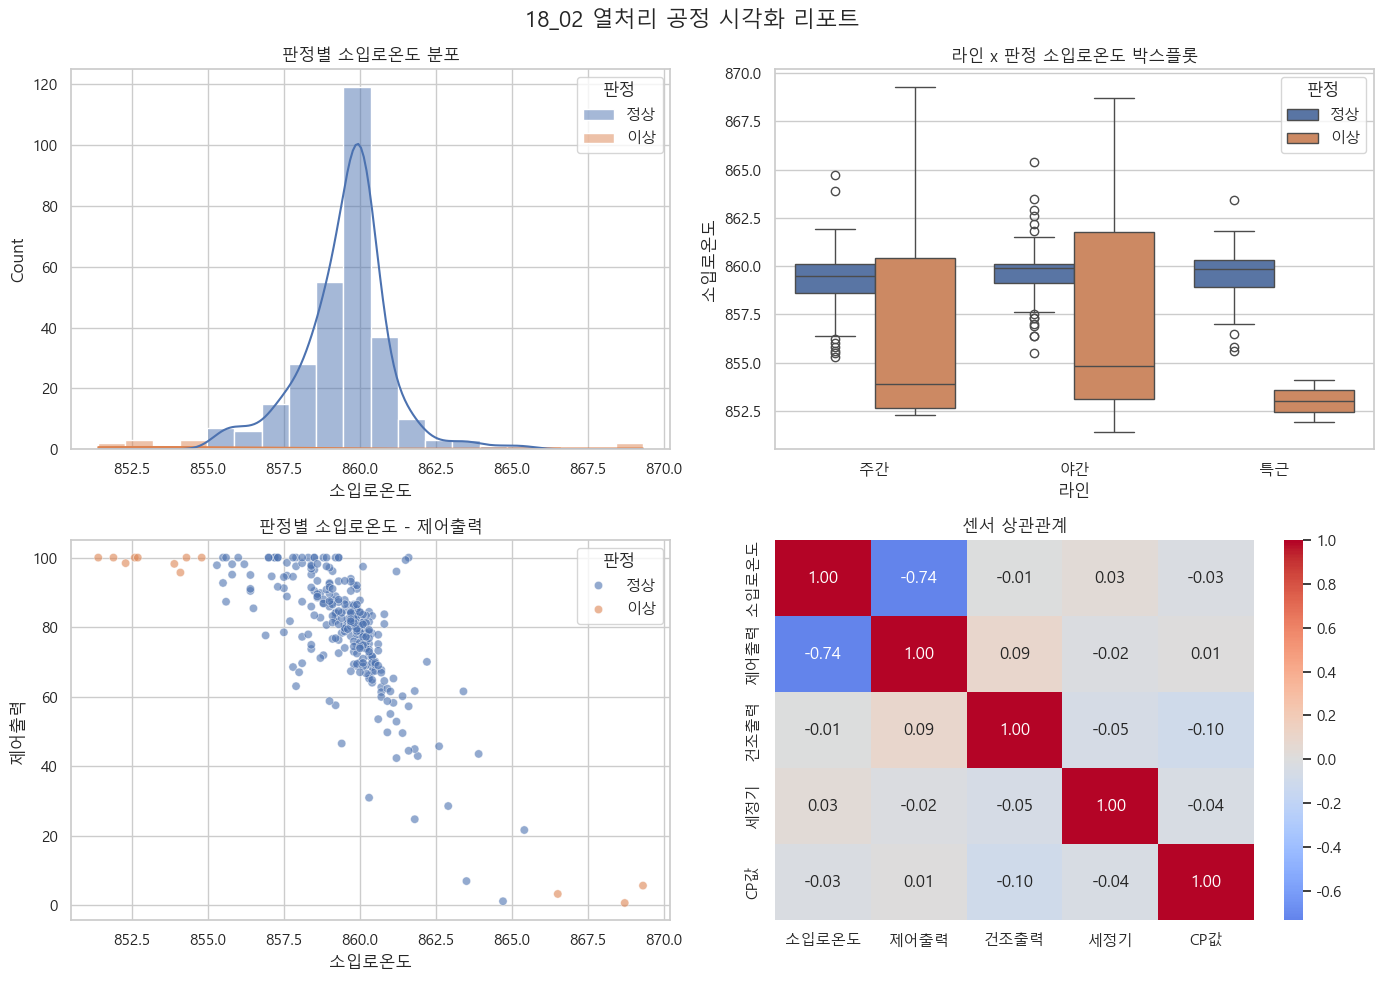

판정  이상  정상   합계  불량률(%)
라인                     
주간   7  93  100     7.0
야간   3  96   99     3.0
특근   2  96   98     2.0


In [8]:
df_6 = pd.read_csv("..\\Data\\18_열처리.csv", encoding="utf-8")

# subplots로 2x2 격자를 만들기
fig, axs = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("18_02 열처리 공정 시각화 리포트", fontsize=16)

# 분포, 박스플롯, 산점도, heatmap을 네 칸에 배치
sns.histplot(data=df_6, x="소입로온도", hue="판정", bins=20, kde=True, ax=axs[0][0])
axs[0][0].set_title("판정별 소입로온도 분포")

sns.boxplot(data=df_6, x="라인", y="소입로온도", hue="판정", ax=axs[0][1])
axs[0][1].set_title("라인 x 판정 소입로온도 박스플롯")

sns.scatterplot(data=df_6, x="소입로온도", y="제어출력", hue="판정", alpha=0.6, ax=axs[1][0])
axs[1][0].set_title("판정별 소입로온도 - 제어출력")

sns.heatmap(data=df_6.corr(numeric_only=True), annot=True, fmt=".2f",
            cmap="coolwarm", center=0, ax=axs[1][1])
axs[1][1].set_title("센서 상관관계")

plt.tight_layout()

# savefig로 리포트를 이미지 파일로 저장 (show보다 먼저 호출해야 빈 파일이 안 됨)
plt.savefig("18_02_실습6_시각화리포트.png", dpi=150, bbox_inches="tight")
plt.show()

# 라인별 불량률까지 표로 한 번 더 정리
표_6 = df_6.groupby(["라인", "판정"]).size().unstack(fill_value=0)
표_6["합계"] = 표_6.sum(axis=1)
표_6["불량률(%)"] = (표_6["이상"] / 표_6["합계"] * 100).round(1)
print(표_6.sort_values("불량률(%)", ascending=False))

# [최종 정리]
# 발견 : 297건 중 이상 12건(4.0%), 라인별로는 주간 7.0% > 야간 3.0% > 특근 2.0%
# 해석 : 센서 5개 중 함께 움직이는 쌍은 소입로온도-제어출력(-0.736) 하나뿐이고,
#        이상 판정은 온도가 높아서가 아니라 정상 범위(855~865도) 밖으로 벗어날 때 발생
# 행동 : 불량률이 두 배 이상 높은 주간 라인을 우선 점검하고,
#        소입로온도를 855~865도 범위 안으로 잡아두는 관리 기준을 검토